In [ ]:
!pip install geopandas requests pandas matplotlib shapely

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
import shapely

print("Everything is working!")

Everything is working!


In [2]:
import requests
import json
from pathlib import Path

# Create folders
Path("data").mkdir(exist_ok=True)

# City of Regina Transit Network
BASE_URL = "https://opengis.regina.ca/arcgis/rest/services/OpenData/TransitNetwork/MapServer"

# Transit Stops = Layer 0
stops_url = f"{BASE_URL}/0/query"

# Transit Routes = Layer 1
routes_url = f"{BASE_URL}/1/query"

params = {
    "where": "1=1",
    "outFields": "*",
    "f": "geojson",
    "returnGeometry": "true"
}

# Download stops
stops_response = requests.get(stops_url, params=params)
stops_response.raise_for_status()

with open("data/transit_stops.geojson", "w") as f:
    f.write(stops_response.text)

# Download routes
routes_response = requests.get(routes_url, params=params)
routes_response.raise_for_status()

with open("data/transit_routes.geojson", "w") as f:
    f.write(routes_response.text)

print("✅ Transit data downloaded successfully!")
print("Stops file:", len(stops_response.text), "characters")
print("Routes file:", len(routes_response.text), "characters")

✅ Transit data downloaded successfully!
Stops file: 347674 characters
Routes file: 1818048 characters


In [3]:
from pathlib import Path

print("Files downloaded:")

for file in Path("data").iterdir():
    print("📁", file)

Files downloaded:
📁 data/transit_routes.geojson
📁 data/transit_stops.geojson


In [4]:
import geopandas as gpd

# Load the transit data
stops = gpd.read_file("data/transit_stops.geojson")
routes = gpd.read_file("data/transit_routes.geojson")

print("Transit stops:", stops.shape)
print("Transit routes:", routes.shape)

Transit stops: (1000, 9)
Transit routes: (22, 9)


In [5]:
stops.head()

,OBJECTID,ONSTREET,ATSTREET,LON,LAT,STOP_ID,STOP_NAME,GLOBALID,geometry
0,76672,14th Ave,Campus Regina (EB),-104.567089,50.44402,0807,14th Ave @ Campus Regina (EB),{7EFFB7C8-A2BB-426C-8B81-B26227EBC921},POINT (-104.5671 50.44403)
1,76673,Froom Cres,14th Ave (SB),-104.56481,50.44364,0808,Froom Cres @ 14th Ave (SB),{A3967669-AA93-44C7-9788-0AC472549036},POINT (-104.56482 50.44365)
2,76674,Dixon Cres,Froom Cres (WB),-104.566139,50.44179,0809,Dixon Cres @ Froom Cres (WB),{B2F2D2D4-F534-4477-9B48-7AA319406C21},POINT (-104.56615 50.4418)
3,76675,Dixon Cres,Arcola Ave (SB),-104.56857,50.44012,0810,Dixon Cres @ Arcola Ave (SB),{6DB48FE9-6288-4D8E-B030-6EEA9DF2398E},POINT (-104.56858 50.44013)
4,76676,University Park Dr,Cunning Cr (NB),-104.55458,50.43489,0811,University Park Dr @ Cunning Cr (NB),{5EC66070-2EE7-4E91-944F-19C25E017E32},POINT (-104.55459 50.4349)


In [6]:
routes.head()

,OBJECTID,SHAPE.LEN,ROUTE_NAME,ROUTE_NUM,ROUTE_ID,SHAPE_ID,ROUTE_COLOR,ROUTE_TEXT_COLOR,geometry
0,11202,23700.792763,HARBOUR LANDING - UNIVERSITY,18,18-48,180005,80FF00,None,"MULTILINESTRING ((-104.62105 50.41732, -104.62..."
1,11203,88320.603997,UNIVERSITY - SHERWOOD ESTATES,3,3-48,30021,A8A800,None,"MULTILINESTRING ((-104.5752 50.40712, -104.574..."
2,11204,47752.650669,ALBERT S EXPRESS - ALBERT N EXPRESS,40,40-48,400004,00CECE,None,"MULTILINESTRING ((-104.64544 50.49777, -104.64..."
3,11205,29358.378389,ARCOLA E EXP - ARCOLA DWTN EXP,60,60-48,600018,808000,None,"MULTILINESTRING ((-104.52419 50.42382, -104.52..."
4,11206,57551.403427,GLENCAIRN - WHITMORE,7,7-48,70009,0000FF,FFFFFF,"MULTILINESTRING ((-104.52937 50.44549, -104.53..."


In [7]:
print("STOP COLUMNS:")
print(stops.columns.tolist())

print("\nROUTE COLUMNS:")
print(routes.columns.tolist())

STOP COLUMNS:
['OBJECTID', 'ONSTREET', 'ATSTREET', 'LON', 'LAT', 'STOP_ID', 'STOP_NAME', 'GLOBALID', 'geometry']

ROUTE COLUMNS:
['OBJECTID', 'SHAPE.LEN', 'ROUTE_NAME', 'ROUTE_NUM', 'ROUTE_ID', 'SHAPE_ID', 'ROUTE_COLOR', 'ROUTE_TEXT_COLOR', 'geometry']


**Cleaning**

**Remove** **duplicates**

In [8]:
print("Stops before:", len(stops))
print("Routes before:", len(routes))

stops = stops.drop_duplicates()
routes = routes.drop_duplicates()

print("\nStops after:", len(stops))
print("Routes after:", len(routes))

Stops before: 1000
Routes before: 22

Stops after: 1000
Routes after: 22


**Check Missing** **Values**

In [9]:
print("Missing values in stops:")
print(stops.isnull().sum())

print("\nMissing values in routes:")
print(routes.isnull().sum())

Missing values in stops:
OBJECTID     0
ONSTREET     0
ATSTREET     5
LON          0
LAT          0
STOP_ID      0
STOP_NAME    0
GLOBALID     0
geometry     0
dtype: int64

Missing values in routes:
OBJECTID             0
SHAPE.LEN            0
ROUTE_NAME           0
ROUTE_NUM            0
ROUTE_ID             0
SHAPE_ID             0
ROUTE_COLOR          0
ROUTE_TEXT_COLOR    16
geometry             0
dtype: int64


**Make sure the geographic data is valid**

In [10]:
print("Stops CRS:", stops.crs)
print("Routes CRS:", routes.crs)

print("\nInvalid stop geometries:", (~stops.geometry.is_valid).sum())
print("Invalid route geometries:", (~routes.geometry.is_valid).sum())

Stops CRS: EPSG:4326
Routes CRS: EPSG:4326

Invalid stop geometries: 0
Invalid route geometries: 0


**KPI'S**

Total number of stops

In [11]:
total_stops = stops["STOP_ID"].nunique()

print("Total Transit Stops:", total_stops)

Total Transit Stops: 1000


Total number of routes

In [12]:
total_routes = routes["ROUTE_NUM"].nunique()

print("Total Routes:", total_routes)

Total Routes: 22


Number of unique streets with transit stops

In [13]:
unique_streets = stops["ONSTREET"].nunique()

print("Unique Streets with Transit Stops:", unique_streets)

Unique Streets with Transit Stops: 166


Display all three together

In [14]:
print("===== REGINA TRANSIT KPIs =====")
print("Total Transit Stops:", total_stops)
print("Total Routes:", total_routes)
print("Unique Streets:", unique_streets)

===== REGINA TRANSIT KPIs =====
Total Transit Stops: 1000
Total Routes: 22
Unique Streets: 166


**find which streets have the most transit stops.**

In [15]:
stops_by_street = (
    stops.groupby("ONSTREET")
    .size()
    .reset_index(name="stop_count")
    .sort_values("stop_count", ascending=False)
)

stops_by_street.head(10)

,ONSTREET,stop_count
52,Dewdney Ave,57
24,Albert St,47
36,Broad St,31
134,Sherwood Dr,30
111,Parliament Ave,26
101,McIntosh St,23
153,Victoria Ave,23
123,Rochdale Blvd,22
4,13th Ave,21
70,Gordon Rd,20


**Show the top 20 streets**

In [16]:
stops_by_street.head(20)

,ONSTREET,stop_count
52,Dewdney Ave,57
24,Albert St,47
36,Broad St,31
134,Sherwood Dr,30
111,Parliament Ave,26
101,McIntosh St,23
153,Victoria Ave,23
123,Rochdale Blvd,22
4,13th Ave,21
70,Gordon Rd,20


**Chart**

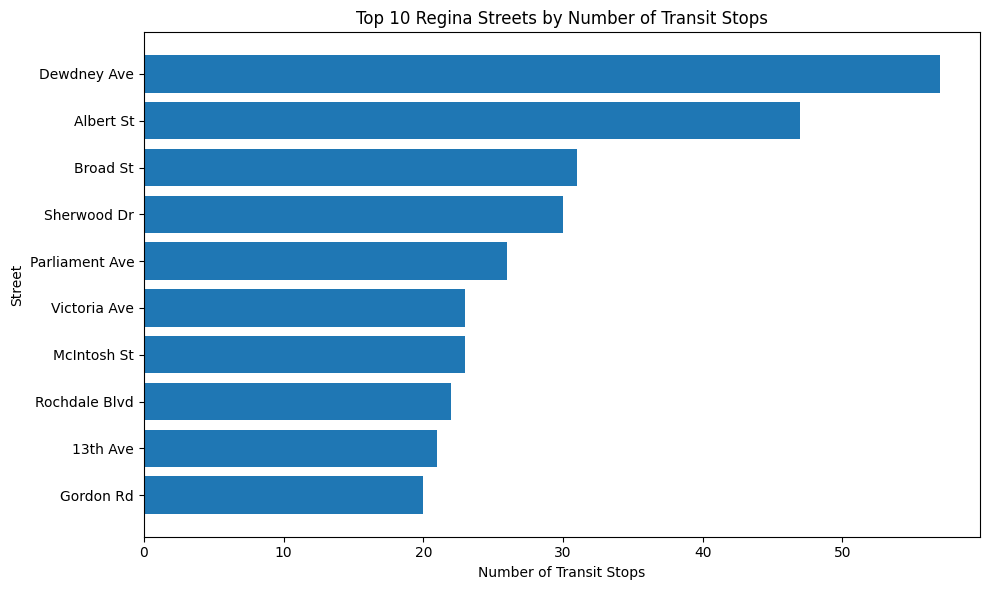

In [17]:
import matplotlib.pyplot as plt

top10 = stops_by_street.head(10).sort_values("stop_count")

plt.figure(figsize=(10, 6))

plt.barh(top10["ONSTREET"], top10["stop_count"])

plt.xlabel("Number of Transit Stops")
plt.ylabel("Street")
plt.title("Top 10 Regina Streets by Number of Transit Stops")

plt.tight_layout()
plt.show()

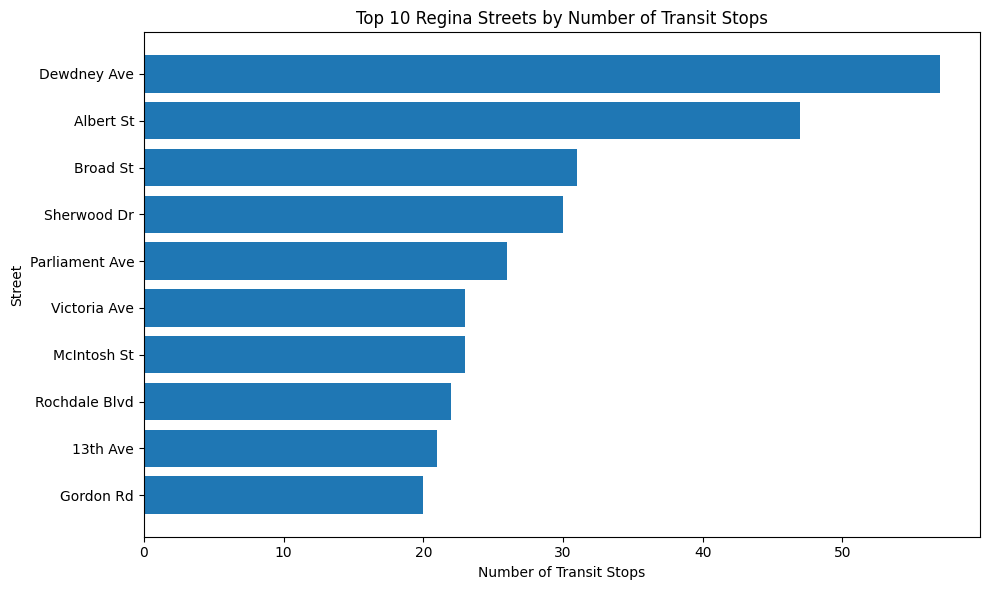

In [18]:
top10 = stops_by_street.head(10).sort_values("stop_count")

plt.figure(figsize=(10, 6))

plt.barh(top10["ONSTREET"], top10["stop_count"])

plt.xlabel("Number of Transit Stops")
plt.ylabel("Street")
plt.title("Top 10 Regina Streets by Number of Transit Stops")

plt.tight_layout()
plt.show()

**Analyze the transit routes**

In [19]:
routes[["ROUTE_NUM", "ROUTE_NAME"]]

,ROUTE_NUM,ROUTE_NAME
0,18,HARBOUR LANDING - UNIVERSITY
1,3,UNIVERSITY - SHERWOOD ESTATES
2,40,ALBERT S EXPRESS - ALBERT N EXPRESS
3,60,ARCOLA E EXP - ARCOLA DWTN EXP
4,7,GLENCAIRN - WHITMORE
5,1,DIEPPE/WESTERRA - BROAD NORTH
6,12,VARSITY PARK - MOUNT ROYAL
7,24,AIRPORT - DOWNTOWN
8,22,UNIVERSITY - ARCOLA EAST
9,2,ARGYLE PARK - WOOD MEADOWS


In [20]:
route_summary = (
    routes.groupby(["ROUTE_NUM", "ROUTE_NAME"])
    .size()
    .reset_index(name="route_records")
    .sort_values("ROUTE_NUM")
)

route_summary

,ROUTE_NUM,ROUTE_NAME,route_records
0,1,DIEPPE/WESTERRA - BROAD NORTH,1
1,10,RCMP - NORMANVIEW,1
2,12,VARSITY PARK - MOUNT ROYAL,1
3,15,HERITAGE WEST - HERITAGE EAST,1
4,16,HAWKSTONE - LAKERIDGE,1
5,17,MAPLE RIDGE WEST - MAPLE RIDGE EAST,1
6,18,HARBOUR LANDING - UNIVERSITY,1
7,2,ARGYLE PARK - WOOD MEADOWS,1
8,21,UNIVERSITY - GLENCAIRN,1
9,22,UNIVERSITY - ARCOLA EAST,1


Convert routes to a projected coordinate system

In [21]:
routes_projected = routes.to_crs(epsg=26913)

print("Original CRS:", routes.crs)
print("Projected CRS:", routes_projected.crs)

Original CRS: EPSG:4326
Projected CRS: EPSG:26913


Calculate the length of every route

In [22]:
routes_projected["route_length_km"] = (
    routes_projected.geometry.length / 1000
)

routes_projected[["ROUTE_NUM", "ROUTE_NAME", "route_length_km"]]

,ROUTE_NUM,ROUTE_NAME,route_length_km
0,18,HARBOUR LANDING - UNIVERSITY,23.700795
1,3,UNIVERSITY - SHERWOOD ESTATES,88.320612
2,40,ALBERT S EXPRESS - ALBERT N EXPRESS,47.752655
3,60,ARCOLA E EXP - ARCOLA DWTN EXP,29.358381
4,7,GLENCAIRN - WHITMORE,57.551409
5,1,DIEPPE/WESTERRA - BROAD NORTH,341.275250
6,12,VARSITY PARK - MOUNT ROYAL,242.596080
7,24,AIRPORT - DOWNTOWN,12.562292
8,22,UNIVERSITY - ARCOLA EAST,47.484312
9,2,ARGYLE PARK - WOOD MEADOWS,66.319749


Sort from longest to shortest

In [23]:
route_length = (
    routes_projected[
        ["ROUTE_NUM", "ROUTE_NAME", "route_length_km"]
    ]
    .sort_values("route_length_km", ascending=False)
)

route_length

,ROUTE_NUM,ROUTE_NAME,route_length_km
5,1,DIEPPE/WESTERRA - BROAD NORTH,341.275250
6,12,VARSITY PARK - MOUNT ROYAL,242.596080
11,10,RCMP - NORMANVIEW,95.305137
1,3,UNIVERSITY - SHERWOOD ESTATES,88.320612
9,2,ARGYLE PARK - WOOD MEADOWS,66.319749
19,5,UPLANDS - DOWNTOWN,60.865714
4,7,GLENCAIRN - WHITMORE,57.551409
14,17,MAPLE RIDGE WEST - MAPLE RIDGE EAST,54.321855
2,40,ALBERT S EXPRESS - ALBERT N EXPRESS,47.752655
8,22,UNIVERSITY - ARCOLA EAST,47.484312


In [24]:
print(
    route_length[
        ["ROUTE_NUM", "ROUTE_NAME", "route_length_km"]
    ].head(10)
)

   ROUTE_NUM                           ROUTE_NAME  route_length_km
5          1        DIEPPE/WESTERRA - BROAD NORTH       341.275250
6         12           VARSITY PARK - MOUNT ROYAL       242.596080
11        10                    RCMP - NORMANVIEW        95.305137
1          3        UNIVERSITY - SHERWOOD ESTATES        88.320612
9          2           ARGYLE PARK - WOOD MEADOWS        66.319749
19         5                   UPLANDS - DOWNTOWN        60.865714
4          7                 GLENCAIRN - WHITMORE        57.551409
14        17  MAPLE RIDGE WEST - MAPLE RIDGE EAST        54.321855
2         40  ALBERT S EXPRESS - ALBERT N EXPRESS        47.752655
8         22             UNIVERSITY - ARCOLA EAST        47.484312


In [25]:
print("Minimum route length:", route_length["route_length_km"].min(), "km")
print("Maximum route length:", route_length["route_length_km"].max(), "km")

Minimum route length: 12.562292301468002 km
Maximum route length: 341.27524999382126 km


In [26]:
# Check how many separate geometry parts each route contains

route_parts = routes.copy()

route_parts["geometry_parts"] = route_parts.geometry.apply(
    lambda geom: len(geom.geoms) if geom.geom_type == "MultiLineString" else 1
)

route_parts[
    ["ROUTE_NUM", "ROUTE_NAME", "geometry_parts"]
].sort_values("geometry_parts", ascending=False)

,ROUTE_NUM,ROUTE_NAME,geometry_parts
5,1,DIEPPE/WESTERRA - BROAD NORTH,22
6,12,VARSITY PARK - MOUNT ROYAL,12
11,10,RCMP - NORMANVIEW,8
19,5,UPLANDS - DOWNTOWN,7
8,22,UNIVERSITY - ARCOLA EAST,6
14,17,MAPLE RIDGE WEST - MAPLE RIDGE EAST,6
1,3,UNIVERSITY - SHERWOOD ESTATES,5
9,2,ARGYLE PARK - WOOD MEADOWS,5
13,16,HAWKSTONE - LAKERIDGE,4
2,40,ALBERT S EXPRESS - ALBERT N EXPRESS,4


In [27]:
route_parts[
    ["ROUTE_NUM", "ROUTE_NAME", "geometry_parts"]
].head(10)

,ROUTE_NUM,ROUTE_NAME,geometry_parts
0,18,HARBOUR LANDING - UNIVERSITY,3
1,3,UNIVERSITY - SHERWOOD ESTATES,5
2,40,ALBERT S EXPRESS - ALBERT N EXPRESS,4
3,60,ARCOLA E EXP - ARCOLA DWTN EXP,3
4,7,GLENCAIRN - WHITMORE,3
5,1,DIEPPE/WESTERRA - BROAD NORTH,22
6,12,VARSITY PARK - MOUNT ROYAL,12
7,24,AIRPORT - DOWNTOWN,2
8,22,UNIVERSITY - ARCOLA EAST,6
9,2,ARGYLE PARK - WOOD MEADOWS,5


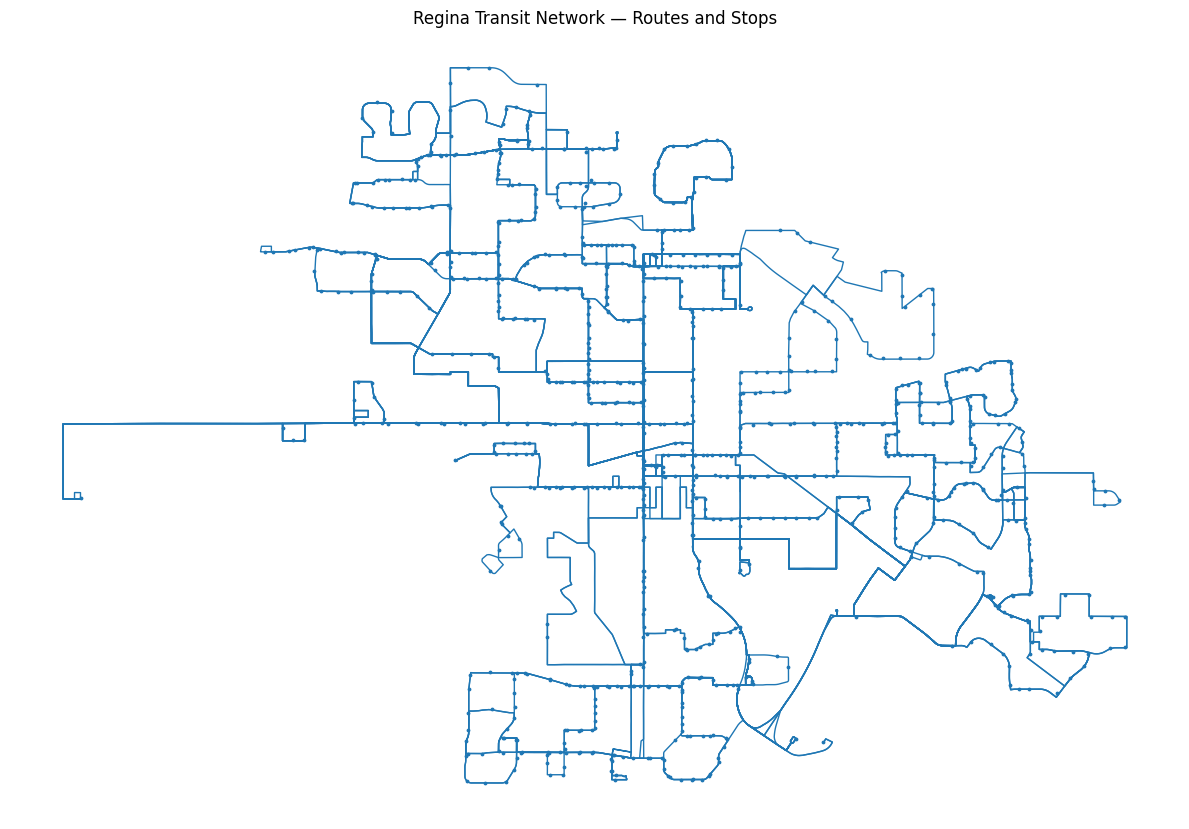

In [28]:
fig, ax = plt.subplots(figsize=(12, 10))

routes.plot(
    ax=ax,
    linewidth=1
)

stops.plot(
    ax=ax,
    markersize=3
)

ax.set_title("Regina Transit Network — Routes and Stops")
ax.set_axis_off()

plt.tight_layout()
plt.show()

Find Where Transit Stops Are Concentrated     ow let's calculate how many stops are located on each street. We already have that information, but this time we'll look at the distribution rather than only the top 10.

In [29]:
print("Minimum stops on a street:", stops_by_street["stop_count"].min())
print("Maximum stops on a street:", stops_by_street["stop_count"].max())
print("Average stops per street:", round(stops_by_street["stop_count"].mean(), 2))
print("Median stops per street:", stops_by_street["stop_count"].median())

Minimum stops on a street: 1
Maximum stops on a street: 57
Average stops per street: 6.02
Median stops per street: 3.0


Create groups

In [30]:
def classify_street(count):
    if count <= 5:
        return "1–5 stops"
    elif count <= 10:
        return "6–10 stops"
    elif count <= 20:
        return "11–20 stops"
    else:
        return "21+ stops"

stops_by_street["stop_group"] = stops_by_street["stop_count"].apply(
    classify_street
)

stops_by_street.head(20)

,ONSTREET,stop_count,stop_group
52,Dewdney Ave,57,21+ stops
24,Albert St,47,21+ stops
36,Broad St,31,21+ stops
134,Sherwood Dr,30,21+ stops
111,Parliament Ave,26,21+ stops
101,McIntosh St,23,21+ stops
153,Victoria Ave,23,21+ stops
123,Rochdale Blvd,22,21+ stops
4,13th Ave,21,21+ stops
70,Gordon Rd,20,11–20 stops


Count how many streets are in each group

In [31]:
street_groups = (
    stops_by_street["stop_group"]
    .value_counts()
    .reindex(["1–5 stops", "6–10 stops", "11–20 stops", "21+ stops"])
    .fillna(0)
    .astype(int)
)

street_groups

,count
stop_group,
1–5 stops,116
6–10 stops,25
11–20 stops,16
21+ stops,9


**Data Quality Analysis**

In [32]:
#This will show us the 5 affected stops.

In [33]:
missing_atstreet = stops[stops["ATSTREET"].isna()]

missing_atstreet[

    ["STOP_ID", "STOP_NAME", "ONSTREET", "ATSTREET", "LON", "LAT"]
]

,STOP_ID,STOP_NAME,ONSTREET,ATSTREET,LON,LAT
390,0452,1060 Dorothy St (SB),1060 Dorothy St (SB),None,-104.682771,50.47669
753,1654,Sandra Schmirler Way (NB),Sandra Schmirler Way (NB),None,-104.651977,50.442697
754,1655,Sandra Schmirler Way (SB),Sandra Schmirler Way (SB),None,-104.652091,50.442611
758,1660,Airport,Airport,None,-104.654582,50.432908
945,1554,5200 Block Parliament Ave (WB),5200 Block Parliament Ave (WB),None,-104.65464,50.41752


In [34]:
print("Stops missing ATSTREET:", len(missing_atstreet))

print(
    "Missing longitude:",
    missing_atstreet["LON"].isna().sum()
)

print(
    "Missing latitude:",
    missing_atstreet["LAT"].isna().sum()
)

Stops missing ATSTREET: 5
Missing longitude: 0
Missing latitude: 0


In [35]:
# now find missing routes
missing_route_color = routes[
    routes["ROUTE_TEXT_COLOR"].isna()
]

print("Routes missing text color:", len(missing_route_color))

missing_route_color[
    ["ROUTE_NUM", "ROUTE_NAME", "ROUTE_COLOR", "ROUTE_TEXT_COLOR"]
]

Routes missing text color: 16


,ROUTE_NUM,ROUTE_NAME,ROUTE_COLOR,ROUTE_TEXT_COLOR
0,18,HARBOUR LANDING - UNIVERSITY,80FF00,None
1,3,UNIVERSITY - SHERWOOD ESTATES,A8A800,None
2,40,ALBERT S EXPRESS - ALBERT N EXPRESS,00CECE,None
3,60,ARCOLA E EXP - ARCOLA DWTN EXP,808000,None
5,1,DIEPPE/WESTERRA - BROAD NORTH,1AA68A,None
6,12,VARSITY PARK - MOUNT ROYAL,00C100,None
7,24,AIRPORT - DOWNTOWN,9D9D9D,None
8,22,UNIVERSITY - ARCOLA EAST,00A600,None
9,2,ARGYLE PARK - WOOD MEADOWS,FF8000,None
10,30,UNIVERSITY - ROCHDALE EXPRESS,FFFF00,None


In [36]:
print("Missing ROUTE_NAME:",
      routes["ROUTE_NAME"].isna().sum())

print("Missing ROUTE_NUM:",
      routes["ROUTE_NUM"].isna().sum())

print("Missing ROUTE_ID:",
      routes["ROUTE_ID"].isna().sum())

print("Missing ROUTE_COLOR:",
      routes["ROUTE_COLOR"].isna().sum())

Missing ROUTE_NAME: 0
Missing ROUTE_NUM: 0
Missing ROUTE_ID: 0
Missing ROUTE_COLOR: 0


In [37]:
# Analyze Transit Stop Locations
stops_by_cross_street = (
    stops.groupby("ATSTREET", dropna=False)
    .size()
    .reset_index(name="stop_count")
    .sort_values("stop_count", ascending=False)
)

stops_by_cross_street.head(20)

,ATSTREET,stop_count
85,Albert St (WB),9
227,Dewdney Ave (NB),7
140,Broad St (EB),7
487,Pasqua St (EB),6
279,Garnet St (WB),6
488,Pasqua St (WB),6
511,Queen St (WB),6
518,Rae St (WB),6
510,Queen St (EB),5
531,Robinson St (WB),5


In [38]:
print(
    "Unique cross-street locations:",
    stops["ATSTREET"].nunique()
)

print(
    "Stops with missing cross-street:",
    stops["ATSTREET"].isna().sum()
)

Unique cross-street locations: 666
Stops with missing cross-street: 5


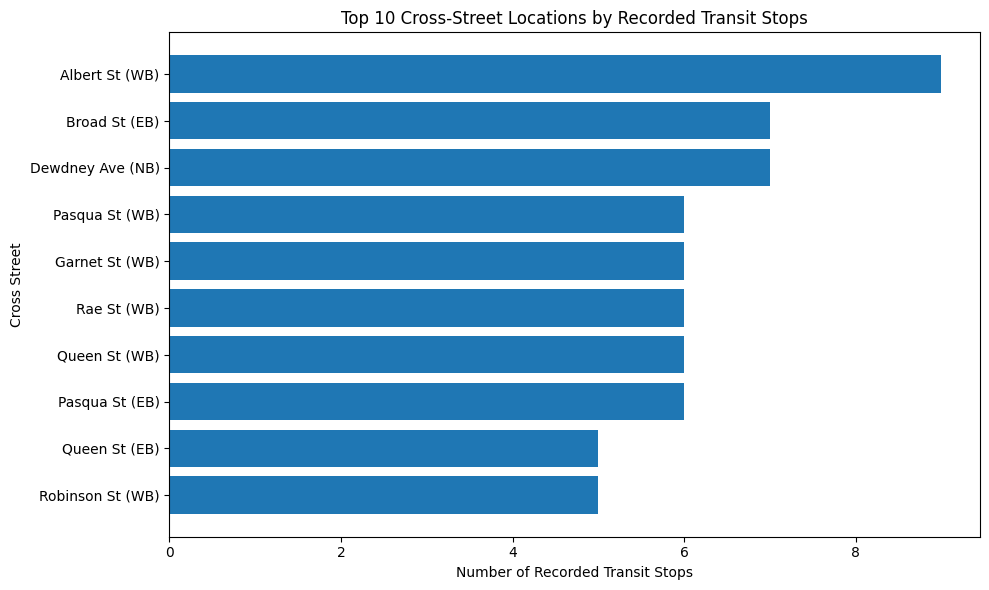

In [39]:
# Create a clean Top 10 Cross-Street Chart
top10_cross_streets = (
    stops_by_cross_street[
        stops_by_cross_street["ATSTREET"].notna()
    ]
    .head(10)
    .sort_values("stop_count")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_cross_streets["ATSTREET"],
    top10_cross_streets["stop_count"]
)

plt.xlabel("Number of Recorded Transit Stops")
plt.ylabel("Cross Street")
plt.title("Top 10 Cross-Street Locations by Recorded Transit Stops")

plt.tight_layout()
plt.show()

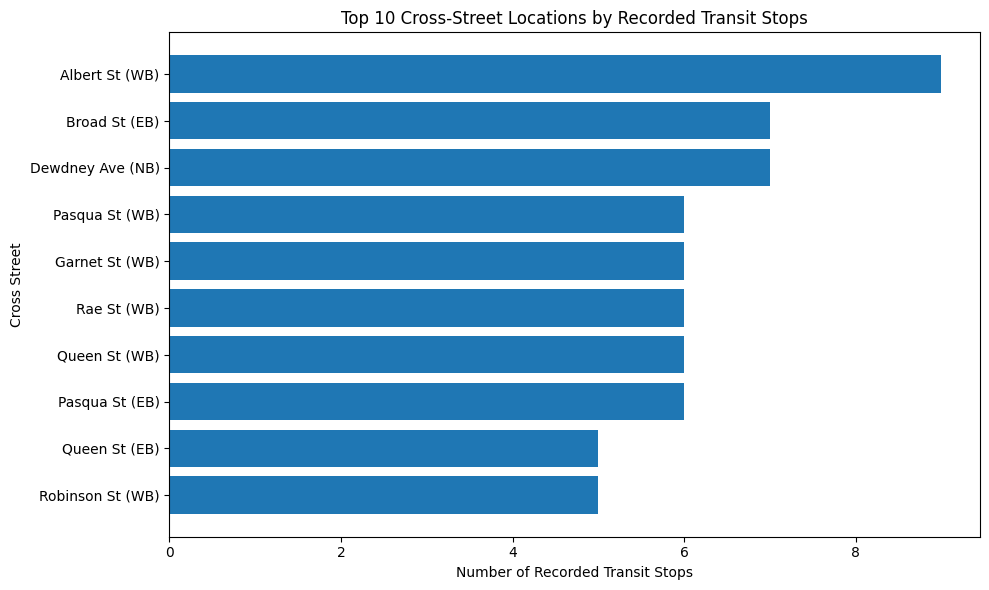

In [40]:
plt.figure(figsize=(10, 6))

plt.barh(
    top10_cross_streets["ATSTREET"],
    top10_cross_streets["stop_count"]
)

plt.xlabel("Number of Recorded Transit Stops")
plt.ylabel("Cross Street")
plt.title("Top 10 Cross-Street Locations by Recorded Transit Stops")

plt.tight_layout()

plt.savefig(
    "top_10_cross_street_locations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
import geopandas as gpd
import requests

wards_url = (
    "https://opengis.regina.ca/arcgis/rest/services/"
    "CGISViewer/ZoningBylaw/MapServer/1/query"
)

params = {
    "where": "1=1",
    "outFields": "*",
    "f": "geojson",
    "returnGeometry": "true"
}

response = requests.get(wards_url, params=params)
response.raise_for_status()

with open("data/regina_wards.geojson", "w") as f:
    f.write(response.text)

wards = gpd.read_file("data/regina_wards.geojson")

print("Number of wards:", len(wards))
print("Columns:")
print(wards.columns.tolist())

wards.head()

Number of wards: 10
Columns:
['OBJECTID', 'ID', 'POPULATION', 'SHAPE.AREA', 'SHAPE.LEN', 'geometry']


,OBJECTID,ID,POPULATION,SHAPE.AREA,SHAPE.LEN,geometry
0,1,5,25465,1.293351e+07,20123.160972,"POLYGON ((-104.5033 50.4717, -104.50358 50.471..."
1,2,7,24702,1.077121e+07,16366.719075,"POLYGON ((-104.60622 50.46952, -104.59839 50.4..."
2,3,8,25149,3.627893e+07,36968.061807,"POLYGON ((-104.77877 50.45489, -104.77878 50.4..."
3,4,3,24397,8.442512e+06,15627.660654,"POLYGON ((-104.60643 50.45211, -104.60793 50.4..."
4,5,10,24528,1.069238e+07,17316.701651,"POLYGON ((-104.65839 50.52073, -104.6584 50.52..."


In [42]:
#Assign every transit stop to a ward
# Make sure both datasets use the same coordinate system
stops = stops.to_crs(wards.crs)

# Assign each transit stop to a ward
stops_with_wards = gpd.sjoin(
    stops,
    wards[["ID", "POPULATION", "geometry"]],
    how="left",
    predicate="within"
)

# Count stops in each ward
stops_by_ward = (
    stops_with_wards
    .groupby(["ID", "POPULATION"])
    .size()
    .reset_index(name="stop_count")
    .sort_values("ID")
)

stops_by_ward

,ID,POPULATION,stop_count
0,1,23725,100
1,2,23172,61
2,3,24397,83
3,4,22143,50
4,5,25465,105
5,6,26746,183
6,7,24702,146
7,8,25149,107
8,9,25263,74
9,10,24528,91


In [43]:
#Calculate transit-stop coverage
stops_by_ward["stops_per_1000"] = (
    stops_by_ward["stop_count"]
    / stops_by_ward["POPULATION"]
) * 1000

stops_by_ward = stops_by_ward.sort_values(
    "stops_per_1000",
    ascending=False
)

stops_by_ward

,ID,POPULATION,stop_count,stops_per_1000
5,6,26746,183,6.842145
6,7,24702,146,5.910453
7,8,25149,107,4.254642
0,1,23725,100,4.214963
4,5,25465,105,4.123306
9,10,24528,91,3.710046
2,3,24397,83,3.402058
8,9,25263,74,2.929185
1,2,23172,61,2.632487
3,4,22143,50,2.258050


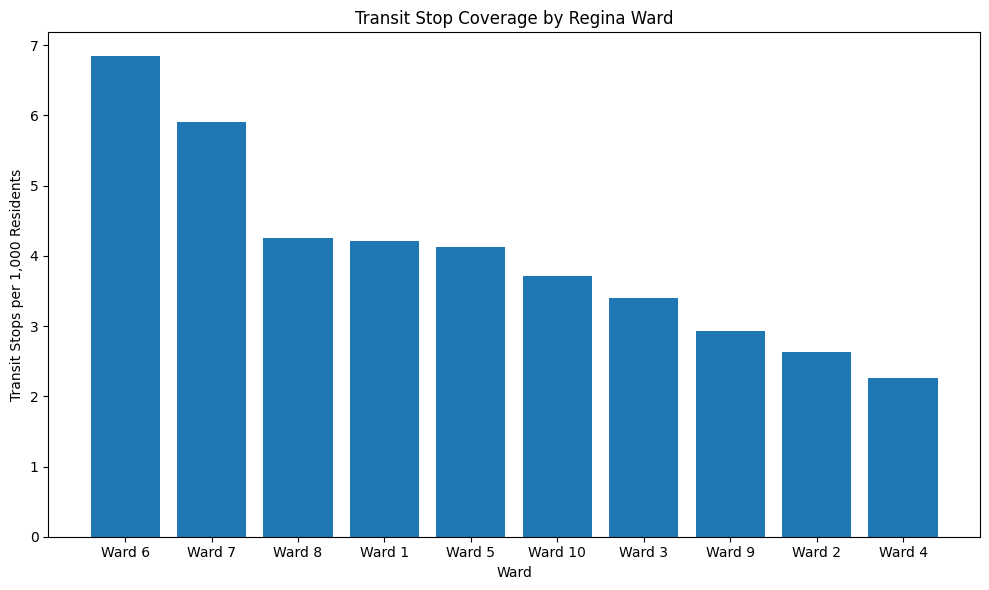

In [44]:
plt.figure(figsize=(10, 6))

plt.bar(
    stops_by_ward["ID"].astype(str),
    stops_by_ward["stops_per_1000"]
)

plt.xlabel("Ward")
plt.ylabel("Transit Stops per 1,000 Residents")
plt.title("Transit Stop Coverage by Regina Ward")

plt.xticks(
    range(len(stops_by_ward)),
    ["Ward " + str(x) for x in stops_by_ward["ID"]]
)

plt.tight_layout()
plt.show()

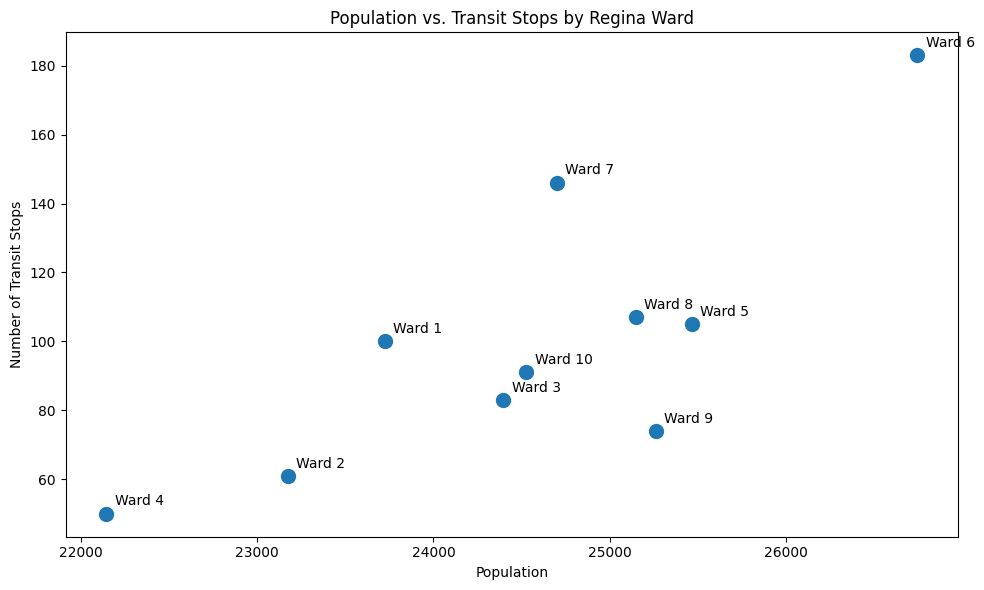

In [45]:
#Population vs. Transit Stops
plt.figure(figsize=(10, 6))

plt.scatter(
    stops_by_ward["POPULATION"],
    stops_by_ward["stop_count"],
    s=100
)

# Label each point with its ward number
for _, row in stops_by_ward.iterrows():
    plt.annotate(
        f"Ward {int(row['ID'])}",
        (row["POPULATION"], row["stop_count"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Population")
plt.ylabel("Number of Transit Stops")
plt.title("Population vs. Transit Stops by Regina Ward")

plt.tight_layout()
plt.show()

In [46]:
#Measure the relationship between population and transit stops
correlation = stops_by_ward["POPULATION"].corr(
    stops_by_ward["stop_count"]
)

print("Correlation between population and transit stops:")
print(round(correlation, 3))

Correlation between population and transit stops:
0.775


In [47]:
#Now we want to identify which wards have more or fewer stops than we'd expect based on their population.
# Calculate the city-wide average stops per resident
overall_rate = (
    stops_by_ward["stop_count"].sum()
    / stops_by_ward["POPULATION"].sum()
)

# Calculate expected stops for each ward based on its population
stops_by_ward["expected_stops"] = (
    stops_by_ward["POPULATION"] * overall_rate
)

# Difference between actual and expected
stops_by_ward["stop_difference"] = (
    stops_by_ward["stop_count"]
    - stops_by_ward["expected_stops"]
)

stops_by_ward[
    ["ID", "POPULATION", "stop_count",
     "expected_stops", "stop_difference"]
].sort_values("stop_difference", ascending=False)

,ID,POPULATION,stop_count,expected_stops,stop_difference
5,6,26746,183,109.038281,73.961719
6,7,24702,146,100.705288,45.294712
7,8,25149,107,102.527620,4.472380
0,1,23725,100,96.722247,3.277753
4,5,25465,105,103.815891,1.184109
9,10,24528,91,99.995923,-8.995923
2,3,24397,83,99.461861,-16.461861
8,9,25263,74,102.992376,-28.992376
1,2,23172,61,94.467773,-33.467773
3,4,22143,50,90.272738,-40.272738


In [48]:
stops_by_ward["difference_percent"] = (
    stops_by_ward["stop_difference"]
    / stops_by_ward["expected_stops"]
) * 100

# Add % sign for display
stops_by_ward["difference_percent"] = (
    stops_by_ward["difference_percent"].round(1).astype(str) + "%"
)

stops_by_ward[
    [
        "ID",
        "POPULATION",
        "stop_count",
        "expected_stops",
        "stop_difference",
        "difference_percent"
    ]
].sort_values("difference_percent", ascending=False)

,ID,POPULATION,stop_count,expected_stops,stop_difference,difference_percent
5,6,26746,183,109.038281,73.961719,67.8%
6,7,24702,146,100.705288,45.294712,45.0%
7,8,25149,107,102.527620,4.472380,4.4%
0,1,23725,100,96.722247,3.277753,3.4%
4,5,25465,105,103.815891,1.184109,1.1%
9,10,24528,91,99.995923,-8.995923,-9.0%
3,4,22143,50,90.272738,-40.272738,-44.6%
1,2,23172,61,94.467773,-33.467773,-35.4%
8,9,25263,74,102.992376,-28.992376,-28.2%
2,3,24397,83,99.461861,-16.461861,-16.6%


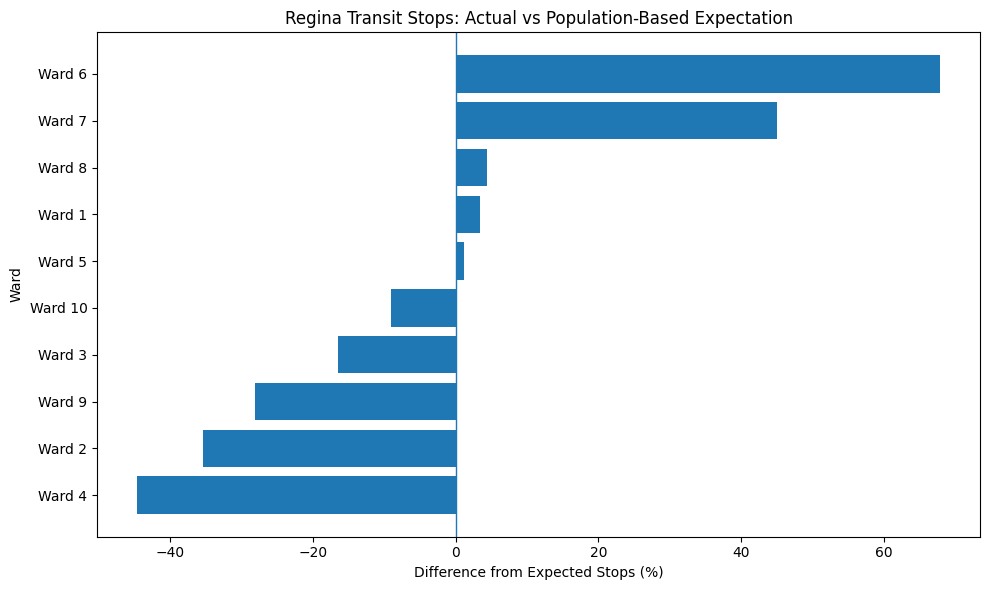

In [49]:
# Part 24 — Percentage Difference from Expected Transit Stops

chart_data = stops_by_ward.copy()

# Sort from lowest to highest percentage difference
stops_by_ward["difference_percent"] = (
    stops_by_ward["stop_difference"]
    / stops_by_ward["expected_stops"]
) * 100

chart_data = stops_by_ward.sort_values("difference_percent")

plt.figure(figsize=(10, 6))

plt.barh(
    "Ward " + chart_data["ID"].astype(str),
    chart_data["difference_percent"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Difference from Expected Stops (%)")
plt.ylabel("Ward")
plt.title("Regina Transit Stops: Actual vs Population-Based Expectation")

plt.tight_layout()
plt.show()

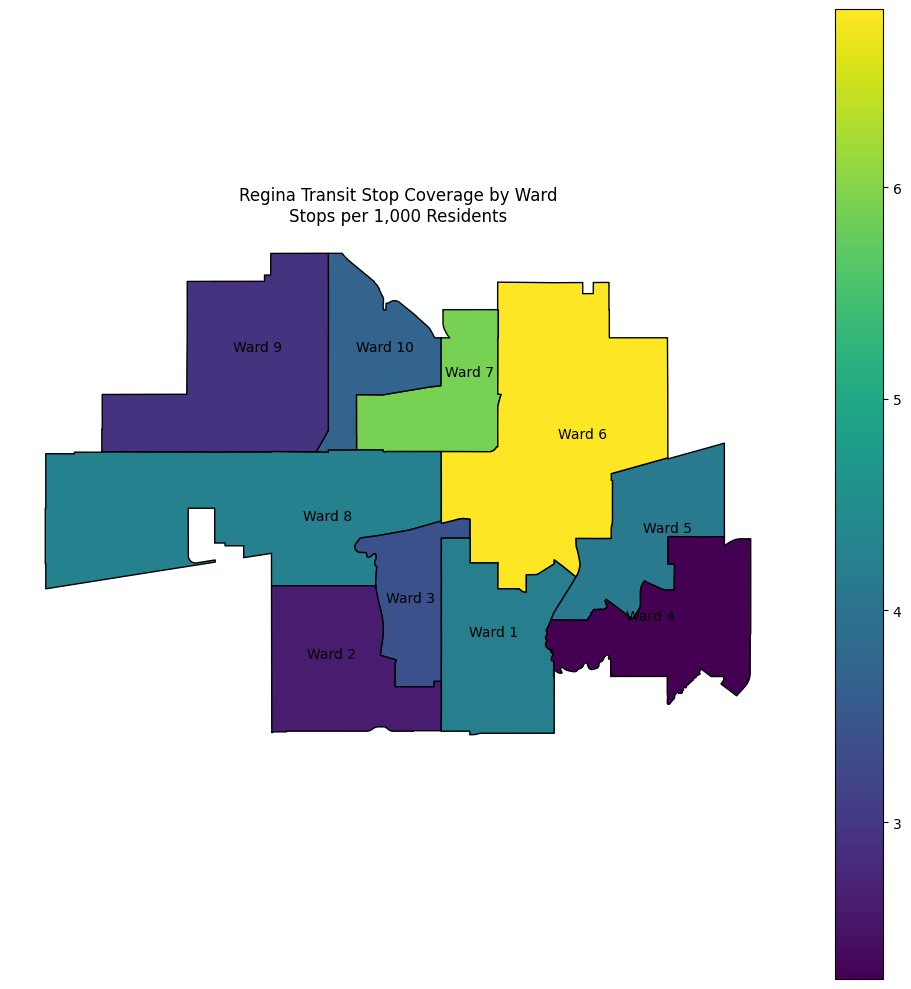

In [50]:
# Part 25 — Transit Stop Coverage Map by Ward

# Add our stop-per-1,000-residents metric to the ward boundaries
wards_map = wards.merge(
    stops_by_ward[["ID", "stop_count", "stops_per_1000"]],
    on="ID",
    how="left"
)

fig, ax = plt.subplots(figsize=(10, 10))

wards_map.plot(
    column="stops_per_1000",
    ax=ax,
    legend=True,
    edgecolor="black"
)

# Add ward numbers to the map
for _, row in wards_map.iterrows():
    point = row.geometry.representative_point()
    ax.annotate(
        f"Ward {int(row['ID'])}",
        (point.x, point.y),
        ha="center",
        fontsize=10
    )

ax.set_title(
    "Regina Transit Stop Coverage by Ward\n"
    "Stops per 1,000 Residents"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [51]:
# Part 26 — Identify the largest differences

highest = stops_by_ward.loc[
    stops_by_ward["difference_percent"].idxmax()
]

lowest = stops_by_ward.loc[
    stops_by_ward["difference_percent"].idxmin()
]

print("Ward with the highest percentage difference:")
print(
    f"Ward {int(highest['ID'])}: "
    f"{highest['difference_percent']:.1f}% above expected"
)

print()

print("Ward with the lowest percentage difference:")
print(
    f"Ward {int(lowest['ID'])}: "
    f"{lowest['difference_percent']:.1f}% below expected"
)

Ward with the highest percentage difference:
Ward 6: 67.8% above expected

Ward with the lowest percentage difference:
Ward 4: -44.6% below expected


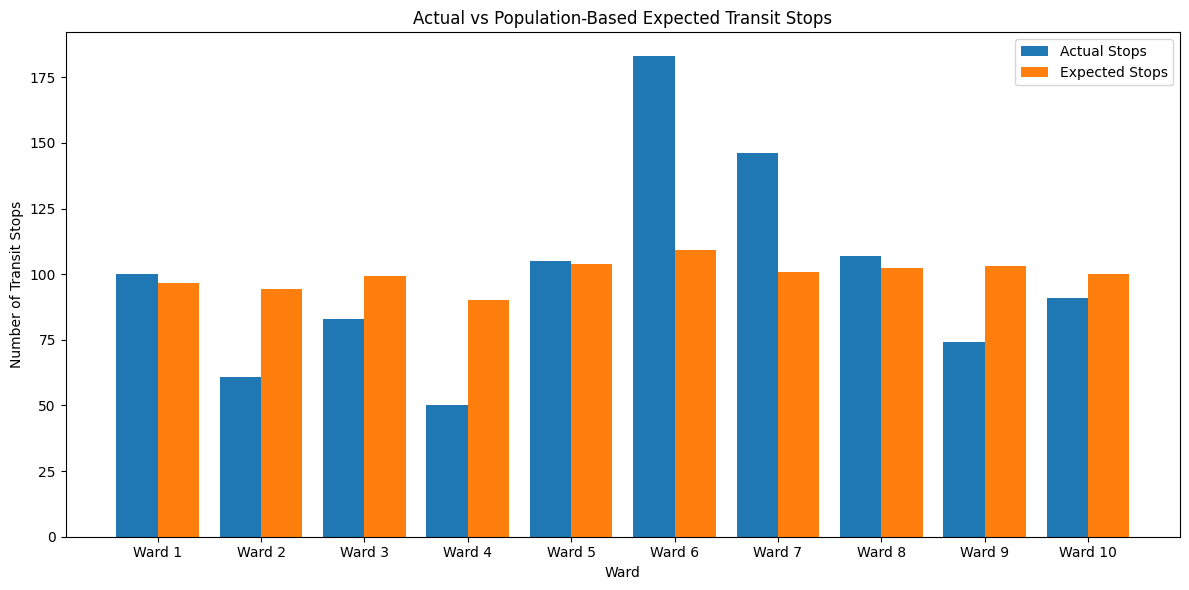

In [52]:
# Part 27 — Actual vs Expected Transit Stops

chart_data = stops_by_ward.sort_values("ID").copy()

plt.figure(figsize=(12, 6))

x = range(len(chart_data))

plt.bar(
    [i - 0.2 for i in x],
    chart_data["stop_count"],
    width=0.4,
    label="Actual Stops"
)

plt.bar(
    [i + 0.2 for i in x],
    chart_data["expected_stops"],
    width=0.4,
    label="Expected Stops"
)

plt.xticks(
    x,
    ["Ward " + str(int(i)) for i in chart_data["ID"]]
)

plt.xlabel("Ward")
plt.ylabel("Number of Transit Stops")
plt.title("Actual vs Population-Based Expected Transit Stops")

plt.legend()

plt.tight_layout()
plt.show()

In [53]:
# Part 28 — Calculate Ward Area in Square Kilometres

# Project wards to a CRS using metres
wards_projected = wards.to_crs(epsg=26913)

# Calculate area in square kilometres
wards_projected["area_km2"] = (
    wards_projected.geometry.area / 1_000_000
)

# View the results
wards_projected[
    ["ID", "area_km2"]
].sort_values("ID")

,ID,area_km2
9,1,15.886082
5,2,15.678019
3,3,8.442513
6,4,16.189339
0,5,12.933509
8,6,36.545989
1,7,10.771216
2,8,36.278939
7,9,25.187343
4,10,10.692383


In [54]:
# Part 29 — Transit Stops per Square Kilometre

# Combine ward area with our transit-stop data
ward_density = wards_projected[
    ["ID", "area_km2"]
].merge(
    stops_by_ward[
        ["ID", "POPULATION", "stop_count"]
    ],
    on="ID",
    how="left"
)

# Calculate stops per square kilometre
ward_density["stops_per_km2"] = (
    ward_density["stop_count"]
    / ward_density["area_km2"]
)

# Display results
ward_density[
    [
        "ID",
        "POPULATION",
        "area_km2",
        "stop_count",
        "stops_per_km2"
    ]
].sort_values("stops_per_km2", ascending=False)

,ID,POPULATION,area_km2,stop_count,stops_per_km2
1,7,24702,10.771216,146,13.554644
3,3,24397,8.442513,83,9.831196
4,10,24528,10.692383,91,8.510731
0,5,25465,12.933509,105,8.118446
9,1,23725,15.886082,100,6.294818
8,6,26746,36.545989,183,5.007389
5,2,23172,15.678019,61,3.890798
6,4,22143,16.189339,50,3.088452
2,8,25149,36.278939,107,2.949370
7,9,25263,25.187343,74,2.937984


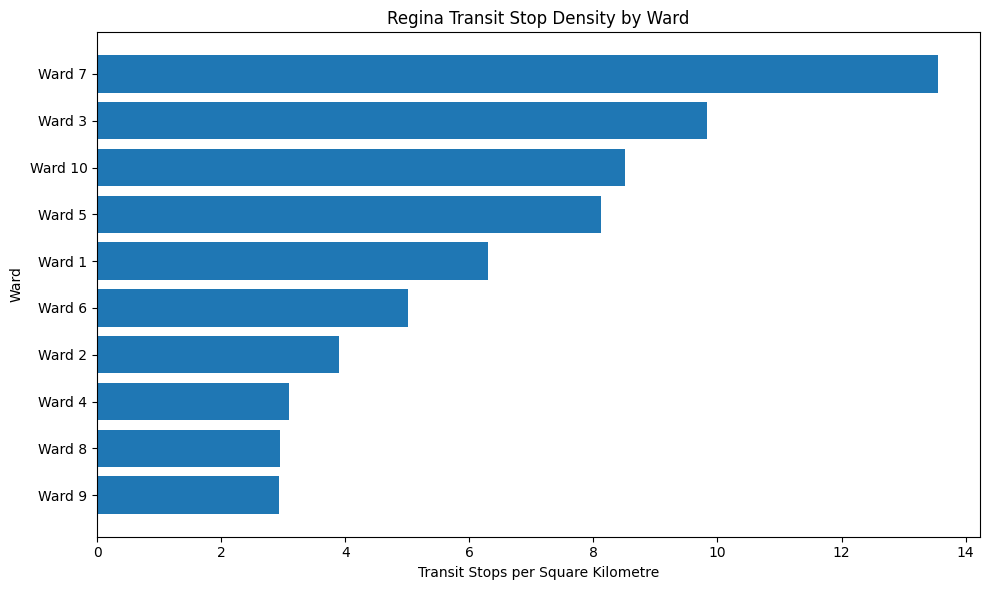

In [55]:
# Part 30 — Transit Stop Density by Ward

chart_data = ward_density.sort_values("stops_per_km2")

plt.figure(figsize=(10, 6))

plt.barh(
    "Ward " + chart_data["ID"].astype(str),
    chart_data["stops_per_km2"]
)

plt.xlabel("Transit Stops per Square Kilometre")
plt.ylabel("Ward")
plt.title("Regina Transit Stop Density by Ward")

plt.tight_layout()
plt.show()

In [56]:
# Part 31 — Calculate Population Density

ward_density["population_per_km2"] = (
    ward_density["POPULATION"]
    / ward_density["area_km2"]
)

ward_density[
    [
        "ID",
        "POPULATION",
        "area_km2",
        "population_per_km2",
        "stop_count",
        "stops_per_km2"
    ]
].sort_values("population_per_km2", ascending=False)

,ID,POPULATION,area_km2,population_per_km2,stop_count,stops_per_km2
3,3,24397,8.442513,2889.779267,83,9.831196
4,10,24528,10.692383,2293.969428,91,8.510731
1,7,24702,10.771216,2293.334368,146,13.554644
0,5,25465,12.933509,1968.916524,105,8.118446
9,1,23725,15.886082,1493.445616,100,6.294818
5,2,23172,15.678019,1477.992835,61,3.890798
6,4,22143,16.189339,1367.751935,50,3.088452
7,9,25263,25.187343,1003.003766,74,2.937984
8,6,26746,36.545989,731.845012,183,5.007389
2,8,25149,36.278939,693.212109,107,2.949370


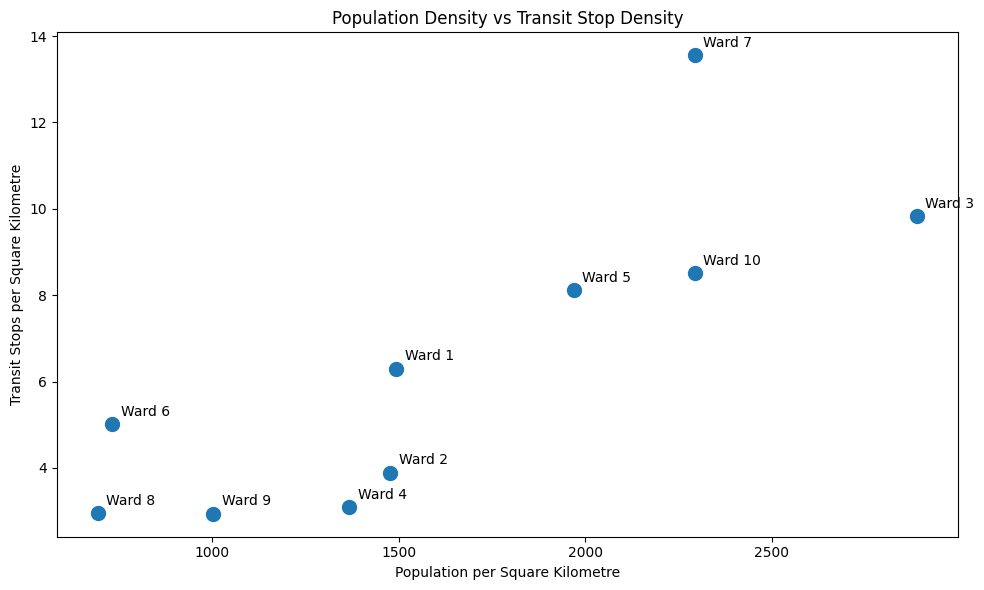

In [57]:
# Part 32 — Population Density vs Transit Stop Density

plt.figure(figsize=(10, 6))

plt.scatter(
    ward_density["population_per_km2"],
    ward_density["stops_per_km2"],
    s=100
)

for _, row in ward_density.iterrows():
    plt.annotate(
        f"Ward {int(row['ID'])}",
        (row["population_per_km2"], row["stops_per_km2"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Population per Square Kilometre")
plt.ylabel("Transit Stops per Square Kilometre")
plt.title("Population Density vs Transit Stop Density")

plt.tight_layout()
plt.show()

In [58]:
# Part 33 — Correlation between Population Density and Transit Stop Density

density_correlation = ward_density["population_per_km2"].corr(
    ward_density["stops_per_km2"]
)

print("Correlation between population density and transit stop density:")
print(round(density_correlation, 3))

Correlation between population density and transit stop density:
0.815


In [59]:
# Part 34 — Population per Transit Stop

ward_density["population_per_stop"] = (
    ward_density["POPULATION"]
    / ward_density["stop_count"]
)

ward_density[
    [
        "ID",
        "POPULATION",
        "stop_count",
        "population_per_stop"
    ]
].sort_values("population_per_stop")

,ID,POPULATION,stop_count,population_per_stop
8,6,26746,183,146.153005
1,7,24702,146,169.191781
2,8,25149,107,235.037383
9,1,23725,100,237.250000
0,5,25465,105,242.523810
4,10,24528,91,269.538462
3,3,24397,83,293.939759
7,9,25263,74,341.391892
5,2,23172,61,379.868852
6,4,22143,50,442.860000


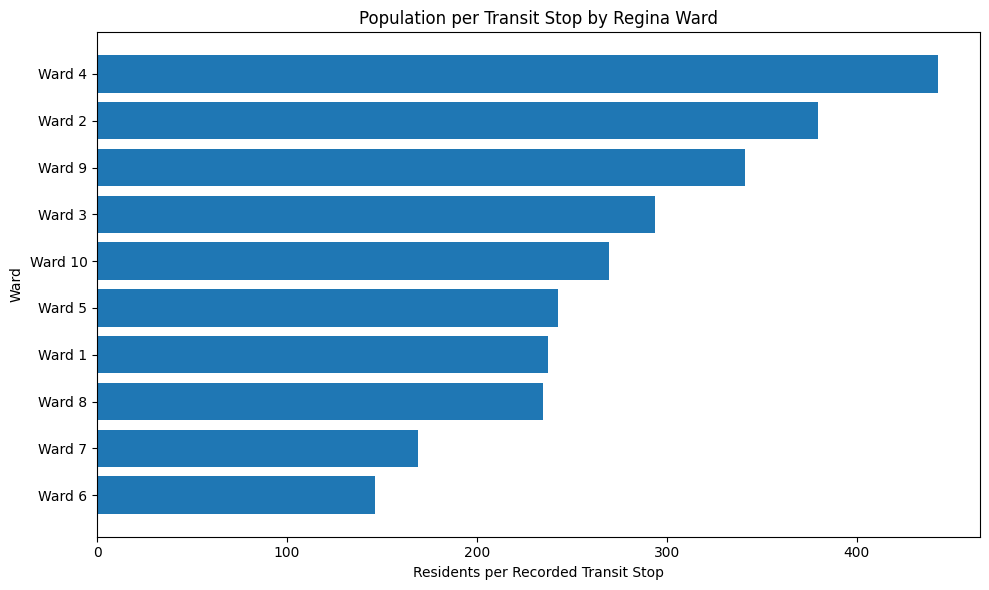

In [60]:
# Part 35 — Population per Transit Stop

chart_data = ward_density.sort_values("population_per_stop")

plt.figure(figsize=(10, 6))

plt.barh(
    "Ward " + chart_data["ID"].astype(str),
    chart_data["population_per_stop"]
)

plt.xlabel("Residents per Recorded Transit Stop")
plt.ylabel("Ward")
plt.title("Population per Transit Stop by Regina Ward")

plt.tight_layout()
plt.show()

In [61]:
# Part 36 — Final Ward Analysis Table

final_ward_analysis = ward_density.merge(
    stops_by_ward[
        [
            "ID",
            "expected_stops",
            "stop_difference",
            "difference_percent"
        ]
    ],
    on="ID",
    how="left"
)

final_ward_analysis = final_ward_analysis[
    [
        "ID",
        "POPULATION",
        "area_km2",
        "population_per_km2",
        "stop_count",
        "stops_per_km2",
        "population_per_stop",
        "expected_stops",
        "stop_difference",
        "difference_percent"
    ]
].sort_values("ID")

final_ward_analysis

,ID,POPULATION,area_km2,population_per_km2,stop_count,stops_per_km2,population_per_stop,expected_stops,stop_difference,difference_percent
9,1,23725,15.886082,1493.445616,100,6.294818,237.250000,96.722247,3.277753,3.388830
5,2,23172,15.678019,1477.992835,61,3.890798,379.868852,94.467773,-33.467773,-35.427714
3,3,24397,8.442513,2889.779267,83,9.831196,293.939759,99.461861,-16.461861,-16.550928
6,4,22143,16.189339,1367.751935,50,3.088452,442.860000,90.272738,-40.272738,-44.612293
0,5,25465,12.933509,1968.916524,105,8.118446,242.523810,103.815891,1.184109,1.140585
8,6,26746,36.545989,731.845012,183,5.007389,146.153005,109.038281,73.961719,67.830965
1,7,24702,10.771216,2293.334368,146,13.554644,169.191781,100.705288,45.294712,44.977492
2,8,25149,36.278939,693.212109,107,2.949370,235.037383,102.527620,4.472380,4.362122
7,9,25263,25.187343,1003.003766,74,2.937984,341.391892,102.992376,-28.992376,-28.150022
4,10,24528,10.692383,2293.969428,91,8.510731,269.538462,99.995923,-8.995923,-8.996290


In [62]:
# Part 37 — Export Final Ward Analysis for SQL

final_ward_analysis.to_csv(
    "data/final_ward_analysis.csv",
    index=False
)

print("✅ Final ward analysis exported successfully!")
print("File: data/final_ward_analysis.csv")
print("Rows:", len(final_ward_analysis))
print("Columns:", len(final_ward_analysis.columns))

✅ Final ward analysis exported successfully!
File: data/final_ward_analysis.csv
Rows: 10
Columns: 10


In [63]:
# Part 38 — Create SQLite Database

import sqlite3
import pandas as pd

# Connect to SQLite database
conn = sqlite3.connect("data/regina_transit.db")

# Load our CSV
df_sql = pd.read_csv("data/final_ward_analysis.csv")

# Create SQL table
df_sql.to_sql(
    "ward_analysis",
    conn,
    if_exists="replace",
    index=False
)

print("✅ SQL database created successfully!")
print("Table: ward_analysis")
print("Rows:", len(df_sql))

✅ SQL database created successfully!
Table: ward_analysis
Rows: 10


In [64]:
# Part 39 — First SQL Analysis

query = """
SELECT
    ID AS ward,
    POPULATION AS population,
    stop_count AS transit_stops
FROM ward_analysis
ORDER BY transit_stops DESC;
"""

result = pd.read_sql_query(query, conn)

result

,ward,population,transit_stops
0,6,26746,183
1,7,24702,146
2,8,25149,107
3,5,25465,105
4,1,23725,100
5,10,24528,91
6,3,24397,83
7,9,25263,74
8,2,23172,61
9,4,22143,50


In [65]:
# Part 40 — Transit Stops per 1,000 Residents

query = """
SELECT
    ID AS ward,
    POPULATION AS population,
    stop_count AS transit_stops,
    ROUND(
        (CAST(stop_count AS REAL) / POPULATION) * 1000,
        2
    ) AS stops_per_1000
FROM ward_analysis
ORDER BY stops_per_1000 DESC;
"""

result = pd.read_sql_query(query, conn)

result

,ward,population,transit_stops,stops_per_1000
0,6,26746,183,6.84
1,7,24702,146,5.91
2,8,25149,107,4.25
3,1,23725,100,4.21
4,5,25465,105,4.12
5,10,24528,91,3.71
6,3,24397,83,3.40
7,9,25263,74,2.93
8,2,23172,61,2.63
9,4,22143,50,2.26


In [66]:
# Part 41 — Wards Below Population-Based Expectation

query = """
SELECT
    ID AS ward,
    POPULATION AS population,
    stop_count AS transit_stops,
    ROUND(expected_stops, 2) AS expected_stops,
    ROUND(stop_difference, 2) AS stop_difference,
    ROUND(difference_percent, 1) AS difference_percent
FROM ward_analysis
WHERE stop_difference < 0
ORDER BY difference_percent ASC;
"""

result = pd.read_sql_query(query, conn)

result

,ward,population,transit_stops,expected_stops,stop_difference,difference_percent
0,4,22143,50,90.27,-40.27,-44.6
1,2,23172,61,94.47,-33.47,-35.4
2,9,25263,74,102.99,-28.99,-28.2
3,3,24397,83,99.46,-16.46,-16.6
4,10,24528,91,100.00,-9.00,-9.0


In [67]:
# Part 42 — Population per Transit Stop

query = """
SELECT
    ID AS ward,
    POPULATION AS population,
    stop_count AS transit_stops,
    ROUND(
        CAST(POPULATION AS REAL) / stop_count,
        2
    ) AS population_per_stop
FROM ward_analysis
ORDER BY population_per_stop ASC;
"""

result = pd.read_sql_query(query, conn)

result

,ward,population,transit_stops,population_per_stop
0,6,26746,183,146.15
1,7,24702,146,169.19
2,8,25149,107,235.04
3,1,23725,100,237.25
4,5,25465,105,242.52
5,10,24528,91,269.54
6,3,24397,83,293.94
7,9,25263,74,341.39
8,2,23172,61,379.87
9,4,22143,50,442.86


In [68]:
# Part 43 — Population Density vs Transit Stop Density

query = """
SELECT
    ID AS ward,
    ROUND(population_per_km2, 2) AS population_density,
    ROUND(stops_per_km2, 2) AS transit_stop_density
FROM ward_analysis
ORDER BY transit_stop_density DESC;
"""

result = pd.read_sql_query(query, conn)

result

,ward,population_density,transit_stop_density
0,7,2293.33,13.55
1,3,2889.78,9.83
2,10,2293.97,8.51
3,5,1968.92,8.12
4,1,1493.45,6.29
5,6,731.85,5.01
6,2,1477.99,3.89
7,4,1367.75,3.09
8,8,693.21,2.95
9,9,1003.00,2.94


In [69]:
# Part 45 — Correlation between Population Density and Transit Stop Density

query = """
SELECT
    population_per_km2,
    stops_per_km2
FROM ward_analysis;
"""

density_data = pd.read_sql_query(query, conn)

correlation = density_data["population_per_km2"].corr(
    density_data["stops_per_km2"]
)

print("Correlation:", round(correlation, 3))

Correlation: 0.815


In [70]:
# Part 44 — Top Wards by Transit Stop Density

query = """
SELECT
    ID AS ward,
    ROUND(population_per_km2, 2) AS population_density,
    ROUND(stops_per_km2, 2) AS transit_stop_density
FROM ward_analysis
ORDER BY stops_per_km2 DESC
LIMIT 5;
"""

result = pd.read_sql_query(query, conn)

result

,ward,population_density,transit_stop_density
0,7,2293.33,13.55
1,3,2889.78,9.83
2,10,2293.97,8.51
3,5,1968.92,8.12
4,1,1493.45,6.29


In [71]:
from google.colab import files

files.download("data/final_ward_analysis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [72]:
routes[["ROUTE_NUM", "ROUTE_NAME"]].to_csv(
    "data/routes_powerbi.csv",
    index=False
)

In [73]:
from google.colab import files

files.download("data/routes_powerbi.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [74]:
stops_by_street.to_csv(
    "data/stops_by_street_powerbi.csv",
    index=False
)

In [75]:
from google.colab import files

files.download("data/stops_by_street_powerbi.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>